**1) Imports**

In [ ]:
import os
import cv2
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from torch.utils.data import Dataset, DataLoader

**2) Device**

In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


**3) Paths**

In [ ]:
BASE_PATH = '/content/drive/MyDrive/KITTI'

IMAGE_DIR = f'{BASE_PATH}/training/image_2'
LABEL_DIR = f'{BASE_PATH}/training/label_2'

**4) Classes**

In [ ]:
CLASSES = ['Car', 'Pedestrian', 'Cyclist']
CLASS_MAP = {c:i+1 for i,c in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES) + 1

**5) Build Valid File List**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
all_images = []

for file in os.listdir(IMAGE_DIR):

    img_id = file.split('.')[0]

    label_path = os.path.join(LABEL_DIR, img_id + '.txt')

    if os.path.exists(label_path):
        all_images.append(file)

print('Total Valid Images:', len(all_images))

Mounted at /content/drive
Total Valid Images: 2953


**6) Split Dataset**

In [ ]:
train_files, temp_files = train_test_split(
    all_images,
    test_size=0.3,
    random_state=42
)

val_files, test_files = train_test_split(
    temp_files,
    test_size=0.5,
    random_state=42
)

print('Train:', len(train_files))
print('Validation:', len(val_files))
print('Test:', len(test_files))

Train: 2067
Validation: 443
Test: 443


**7) Dataset Class (FIXED)**

In [ ]:
class KITTIDataset(Dataset):

    def __init__(self, image_dir, label_dir, files):

        self.image_dir = image_dir
        self.label_dir = label_dir
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        img_name = self.files[idx]

        img_path = os.path.join(self.image_dir, img_name)

        label_name = img_name.replace('.png', '.txt')
        label_path = os.path.join(self.label_dir, label_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        boxes = []
        labels = []

        with open(label_path, 'r') as f:

            lines = f.readlines()

            for line in lines:

                parts = line.strip().split()

                class_name = parts[0]

                if class_name not in CLASS_MAP:
                    continue

                x1 = float(parts[4])
                y1 = float(parts[5])
                x2 = float(parts[6])
                y2 = float(parts[7])

                boxes.append([x1, y1, x2, y2])
                labels.append(CLASS_MAP[class_name])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels
        }

        image = F.to_tensor(image)

        return image, target

**8) Collate Function**

In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))

**9) Create DataLoaders**

In [ ]:
train_dataset = KITTIDataset(IMAGE_DIR, LABEL_DIR, train_files)
val_dataset = KITTIDataset(IMAGE_DIR, LABEL_DIR, val_files)
test_dataset = KITTIDataset(IMAGE_DIR, LABEL_DIR, test_files)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)


test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)

**10) Build Faster R-CNN Model**

In [ ]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    NUM_CLASSES
)

model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 193MB/s]


**11) Optimizer**

In [ ]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.Adam(params, lr=1e-4)

**12) Training Loop**

In [ ]:
num_epochs = 10

train_losses = []

for epoch in range(num_epochs):

    model.train()

    epoch_loss = 0

    progress = tqdm(train_loader)

    for images, targets in progress:

        images = [img.to(DEVICE) for img in images]

        targets = [
            {k: v.to(DEVICE) for k, v in t.items()}
            for t in targets
        ]

        loss_dict = model(images, targets)

        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()

        losses.backward()

        optimizer.step()

        epoch_loss += losses.item()

        progress.set_description(
            f'Epoch {epoch+1}/{num_epochs} Loss: {losses.item():.4f}'
        )


    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f'Average Loss (Epoch {epoch+1}): {avg_loss:.4f}')

Epoch 1/10 Loss: 0.3755: 100%|██████████| 517/517 [19:12<00:00,  2.23s/it]


Average Loss (Epoch 1): 0.4140


Epoch 2/10 Loss: 0.3620: 100%|██████████| 517/517 [07:34<00:00,  1.14it/s]


Average Loss (Epoch 2): 0.3000


Epoch 3/10 Loss: 0.1198: 100%|██████████| 517/517 [07:30<00:00,  1.15it/s]


...

Average Loss (Epoch 8): 0.1534


Epoch 9/10 Loss: 0.1381: 100%|██████████| 517/517 [07:33<00:00,  1.14it/s]


Average Loss (Epoch 9): 0.1422


Epoch 10/10 Loss: 0.0594: 100%|██████████| 517/517 [07:31<00:00,  1.15it/s]

Average Loss (Epoch 10): 0.1314


**13) Plot Training Loss**

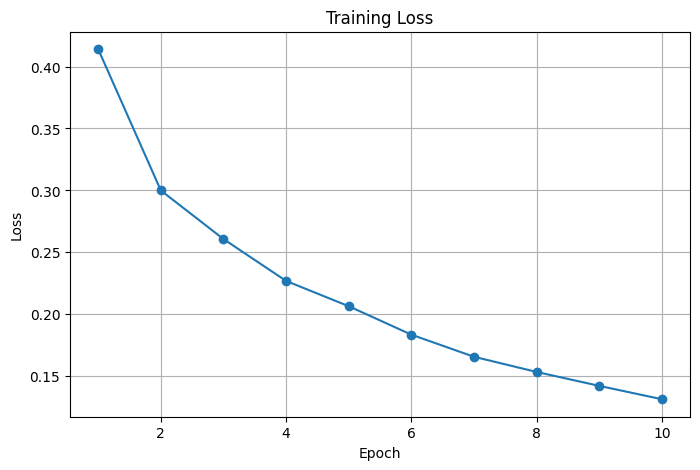

In [ ]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, marker='o')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.show()

**14) IoU Function**

In [ ]:
def calculate_iou(box1, box2):

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union = area1 + area2 - inter

    if union == 0:
        return 0

    return inter / union

**15) Full Evaluation Function**

In [ ]:
from collections import defaultdict


def evaluate_model(model, loader, device, threshold=0.5):

    model.eval()

    true_labels = []
    pred_labels = []

    total_iou = []

    tp = 0
    fp = 0
    fn = 0

    with torch.no_grad():

        for images, targets in tqdm(loader):

            images = [img.to(device) for img in images]

            outputs = model(images)

            for output, target in zip(outputs, targets):

                gt_boxes = target['boxes'].numpy()
                gt_labels = target['labels'].numpy()

                pred_boxes = output['boxes'].cpu().numpy()
                pred_scores = output['scores'].cpu().numpy()
                pred_classes = output['labels'].cpu().numpy()

                used_gt = set()
                for pred_box, pred_score, pred_class in zip(
                    pred_boxes,
                    pred_scores,
                    pred_classes
                ):

                    if pred_score < threshold:
                        continue

                    best_iou = 0
                    best_idx = -1

                    for idx, gt_box in enumerate(gt_boxes):

                        iou = calculate_iou(pred_box, gt_box)

                        if iou > best_iou:
                            best_iou = iou
                            best_idx = idx

                    if best_iou >= 0.5:

                        tp += 1

                        total_iou.append(best_iou)

                        true_labels.append(gt_labels[best_idx])
                        pred_labels.append(pred_class)

                        used_gt.add(best_idx)

                    else:
                        fp += 1

                fn += len(gt_boxes) - len(used_gt)

    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)

    accuracy = np.mean(np.array(true_labels) == np.array(pred_labels))

    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    mean_iou = np.mean(total_iou) if len(total_iou) > 0 else 0

    print('\n===== Evaluation Results =====')
    print(f'Precision : {precision:.4f}')
    print(f'Recall    : {recall:.4f}')
    print(f'Accuracy  : {accuracy:.4f}')
    print(f'F1 Score  : {f1:.4f}')
    print(f'Mean IoU  : {mean_iou:.4f}')

    return true_labels, pred_labels

**16) Run Evaluation**

In [ ]:
true_labels, pred_labels = evaluate_model(
    model,
    test_loader,
    DEVICE
)

100%|██████████| 111/111 [02:59<00:00,  1.62s/it]


===== Evaluation Results =====
Precision : 0.8431
Recall    : 0.8966
Accuracy  : 0.9747
F1 Score  : 0.8690
Mean IoU  : 0.8492


**17) Confusion Matrix**

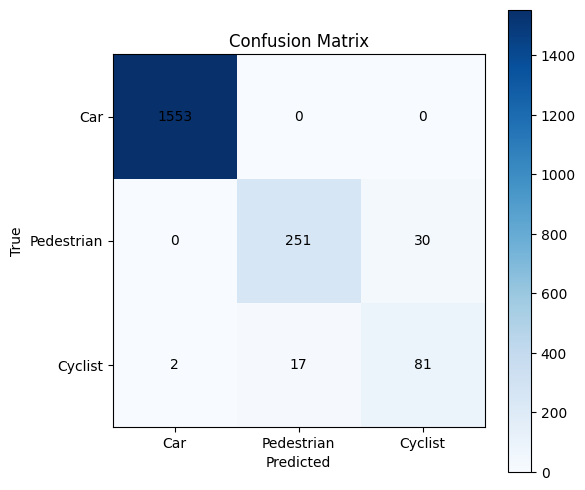

In [ ]:
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,6))

plt.imshow(cm, interpolation='nearest', cmap='Blues')

plt.title('Confusion Matrix')

plt.colorbar()

classes = ['Car', 'Pedestrian', 'Cyclist']

plt.xticks(range(len(classes)), classes)
plt.yticks(range(len(classes)), classes)

plt.xlabel('Predicted')
plt.ylabel('True')

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i,j], ha='center', va='center')

plt.show()

**18) Classification Report**

In [ ]:
print(classification_report(
    true_labels,
    pred_labels,
    target_names=CLASSES
))

              precision    recall  f1-score   support

         Car       1.00      1.00      1.00      1553
  Pedestrian       0.94      0.89      0.91       281
     Cyclist       0.73      0.81      0.77       100

    accuracy                           0.97      1934
   macro avg       0.89      0.90      0.89      1934
weighted avg       0.98      0.97      0.98      1934



**19) Visualization Function**

In [ ]:
import random


def visualize_prediction(model, dataset, index=0, threshold=0.5):

    model.eval()

    image, target = dataset[index]

    with torch.no_grad():
        output = model([image.to(DEVICE)])[0]

    img = image.permute(1,2,0).numpy()
    img = (img * 255).astype(np.uint8)

    for box, score, label in zip(
        output['boxes'],
        output['scores'],
        output['labels']
    ):

        if score < threshold:
            continue

        x1,y1,x2,y2 = box.int().cpu().numpy()

        class_name = CLASSES[label-1]

        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

        cv2.putText(
            img,
            class_name,
            (x1,y1-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255,0,0),
            2
        )

    plt.figure(figsize=(12,8))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

**20) Test Visualization**

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch


def visualize_prediction(model, dataset, index=0, threshold=0.5):

    model.eval()

    image, target = dataset[index]

    with torch.no_grad():

        output = model([image.to(DEVICE)])[0]

    img = image.permute(1,2,0).cpu().numpy()

    img = (img * 255).clip(0,255).astype(np.uint8)

    img = np.ascontiguousarray(img)

    for box, score, label in zip(
        output['boxes'],
        output['scores'],
        output['labels']
    ):

        if score < threshold:
            continue

        x1, y1, x2, y2 = box.int().cpu().numpy()

        class_name = CLASSES[label - 1]

        cv2.rectangle(
            img,
            (x1, y1),
            (x2, y2),
            (0,255,0),
            2
        )

        cv2.putText(
            img,
            class_name,
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255,0,0),
            2
        )

    plt.figure(figsize=(12,8))

    plt.imshow(img)

    plt.axis('off')

    plt.show()

**21) Save Model**

In [ ]:
torch.save(model.state_dict(), 'kitti_detector.pth')

In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import functional as F


def test_single_image(model, image_path, threshold=0.5):

    model.eval()


    image = cv2.imread(image_path)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


    image_tensor = F.to_tensor(image_rgb).to(DEVICE)


    with torch.no_grad():

        output = model([image_tensor])[0]


    img = image_rgb.copy()


    for box, score, label in zip(
        output['boxes'],
        output['scores'],
        output['labels']
    ):

        if score < threshold:
            continue

        x1, y1, x2, y2 = box.int().cpu().numpy()

        class_name = CLASSES[label - 1]

        confidence = float(score)

        cv2.rectangle(
            img,
            (x1, y1),
            (x2, y2),
            (0,255,0),
            2
        )

        cv2.putText(
            img,
            f'{class_name}: {confidence:.2f}',
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255,0,0),
            2
        )


    plt.figure(figsize=(14,8))

    plt.imshow(img)

    plt.axis('off')

    plt.show()

In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import functional as F


def test_single_image(model, image_path, threshold=0.2):

    model.eval()


    image = cv2.imread(image_path)

    if image is None:
        print("❌ Image not found")
        return

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


    image_tensor = F.to_tensor(image_rgb).to(DEVICE)


    with torch.no_grad():

        output = model([image_tensor])[0]

    print("Detected Objects:", len(output['boxes']))

    img = image_rgb.copy()


    for box, score, label in zip(
        output['boxes'],
        output['scores'],
        output['labels']
    ):

        if score < threshold:
            continue

        x1, y1, x2, y2 = box.int().cpu().numpy()

        class_name = CLASSES[label - 1]

        confidence = float(score)

        cv2.rectangle(
            img,
            (x1, y1),
            (x2, y2),
            (0,255,0),
            2
        )

        cv2.putText(
            img,
            f'{class_name}: {confidence:.2f}',
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255,0,0),
            2
        )

    plt.figure(figsize=(15,8))

    plt.imshow(img)

    plt.axis('off')

    plt.show()

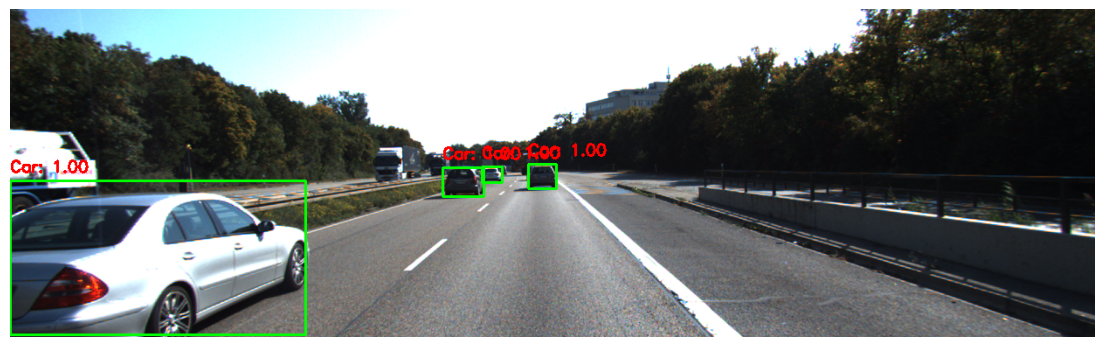

In [ ]:
image_path = '/content/drive/MyDrive/KITTI/testing/image_2/000010.png'

test_single_image(model, image_path)